In [133]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [134]:
filename1 = "affected_laplacian_zero_dimension.pkl"
filename2 = "affected_laplacian_first_dimension.pkl"
filename3 = "affected_laplacian_second_dimension.pkl"
filename4 = "healthy_laplacian_zero_dimension.pkl"
filename5 = "healthy_laplacian_first_dimension.pkl"
filename6 = "healthy_laplacian_second_dimension.pkl"

In [135]:
with open(filename1, "rb") as f:
    affected_laplacian_red_feature = pickle.load(f)

In [136]:
with open(filename2, "rb") as f:
    affected_laplacian_green_feature = pickle.load(f)

In [137]:
with open(filename3, "rb") as f:
    affected_laplacian_blue_feature = pickle.load(f)

In [138]:
with open(filename4, "rb") as f:
    healthy_laplacian_red_feature = pickle.load(f)

In [139]:
with open(filename5, "rb") as f:
    healthy_laplacian_green_feature = pickle.load(f)

In [140]:
with open(filename6, "rb") as f:
    healthy_laplacian_blue_feature = pickle.load(f)

In [141]:
filename7 = "affected_area_feature_2.pkl"
filename8 = "healthy_area_feature_2.pkl"

In [142]:
with open(filename7, "rb") as f:
    affected_area_feature = pickle.load(f)

In [143]:
with open(filename8, "rb") as f:
    healthy_area_feature = pickle.load(f)

In [144]:
filename9  = "affected_perimeter_feature.pkl"
filename10 = "healthy_perimeter_feature.pkl"

In [145]:
with open(filename9, "rb") as f:
    affected_perimeter_feature = pickle.load(f)

In [146]:
with open(filename10, "rb") as f:
    healthy_perimeter_feature = pickle.load(f)

In [147]:
print(len(affected_laplacian_red_feature))
print(len(affected_laplacian_green_feature))
print(len(affected_laplacian_blue_feature))
print(len(affected_area_feature))
print(len(affected_perimeter_feature))

335
335
335
335
335


In [148]:
print(len(healthy_laplacian_red_feature))
print(len(healthy_laplacian_green_feature))
print(len(healthy_laplacian_blue_feature))
print(len(healthy_area_feature))
print(len(healthy_perimeter_feature))

413
413
413
413
413


In [149]:
red_feature = affected_laplacian_red_feature + healthy_laplacian_red_feature
green_feature = affected_laplacian_green_feature + healthy_laplacian_green_feature
blue_feature = affected_laplacian_blue_feature + healthy_laplacian_blue_feature
area_feature = affected_area_feature + healthy_area_feature
perimeter_feature = affected_perimeter_feature + healthy_perimeter_feature

In [150]:
print(len(red_feature))
print(len(green_feature))
print(len(blue_feature))
print(len(area_feature))
print(len(perimeter_feature))

748
748
748
748
748


In [151]:
label_zero = [0] * 335
label_one = [1] * 413
label = label_zero + label_one

In [152]:
print(len(label))

748


In [153]:
# Create the dataset
dataset = pd.DataFrame({
    'LaplacianRed': red_feature,
    'LaplacianGreen': green_feature,
    'LaplacianBlue': blue_feature,
    'Area': area_feature,
    'Perimeter': perimeter_feature,
    'Label': label
})

In [154]:
dataset = dataset.sample(frac=1).reset_index(drop=True)

In [155]:
dataset

,LaplacianRed,LaplacianGreen,LaplacianBlue,Area,Perimeter,Label
0,9467267,8232460,4068721,27401.0,1053.646749,0
1,8642152,5672948,3910308,33433.0,1102.007140,0
2,3028255,5006366,2468803,29638.5,905.656854,1
3,9184327,8510031,2804586,16807.0,1477.269114,0
4,9062036,8511491,2852713,32516.0,1112.090400,0
...,...,...,...,...,...,...
743,6227908,4357895,3467439,21444.5,689.168611,0
744,2612447,10105037,1965140,49561.5,699.653891,1
745,8234417,8082617,4835222,38779.0,1024.225396,0
746,6749908,7902784,3947500,8836.5,913.920914,1


In [156]:
X = dataset.drop('Label', axis=1)
y = dataset['Label']

In [157]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [158]:
model = DecisionTreeClassifier(random_state=42)

In [159]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [160]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90        75
           1       0.91      0.89      0.90        75

    accuracy                           0.90       150
   macro avg       0.90      0.90      0.90       150
weighted avg       0.90      0.90      0.90       150



In [161]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [162]:
print(cm)

[[68  7]
 [ 8 67]]


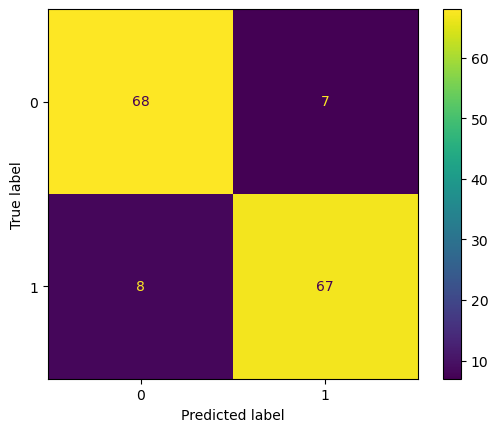

In [163]:
# Optional: Display as a plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

/var/folders/x1/jqxrt94s0ggfl8m0z5bftpz80000gn/T/ipykernel_1460/1556446823.py:9: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


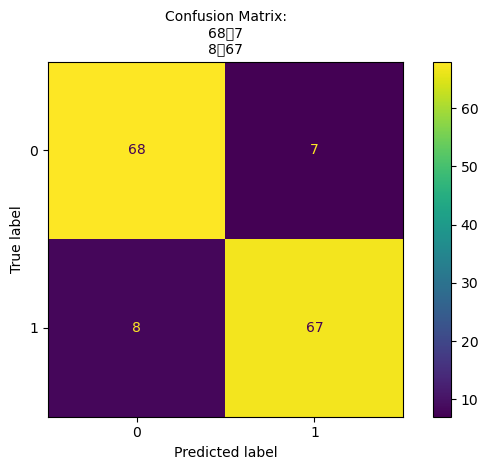

In [164]:
# Your code to compute cm and model.classes_ should be above this
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()

# Convert confusion matrix to string and set it as title
cm_string = '\n'.join(['\t'.join(map(str, row)) for row in cm])
plt.title(f"Confusion Matrix:\n{cm_string}", fontsize=10)

plt.tight_layout()
plt.show()